# 05 — Vision Transformer (ViT-B/16)
**WikiArt Painting Classifier** — NOVA IMS Deep Learning 2025/2026

This notebook fine-tunes a pretrained **Vision Transformer (ViT-B/16)** for 23-class artist classification on the WikiArt dataset. Unlike CNNs, ViT splits each image into 16×16 patches, treats them as tokens, and processes them through multi-head self-attention blocks — enabling the model to capture long-range compositional relationships across a painting.

The backbone is initialised from **ImageNet-21K** pretrained weights via `keras-hub`, with a custom classification head trained on our dataset.

**Training improvements applied:**
- **AdamW** optimizer with weight decay (0.01) instead of plain Adam
- **Cosine learning rate schedule** with 10% linear warmup
- **Increased dropout** (0.3) with an intermediate dense layer (256 units, GELU)
- **Label smoothing** (0.1) to reduce overconfidence and improve generalisation
- **20 epochs** with early stopping (patience=5)

This notebook covers:
1. Loading the pre-processed WikiArt dataset.
2. Building the improved ViT-B/16 model.
3. Fine-tuning with cosine schedule, early stopping, and checkpointing.
4. Analysing learning curves and saving results.

In [1]:
import sys
import os
import math
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from src.data_loader import build_datasets
from src.models.vit import build_vit_model

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 3e-5
DROPOUT_RATE = 0.3
DENSE_UNITS = 256
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.1
WARMUP_FRACTION = 0.1

c:\Users\Administrator\Documents\Master\DL\WikiArt-DeepLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Loading the Pre-processed WikiArt Dataset
We reuse the shared `build_datasets` pipeline. Images are already resized to 224×224 and normalised to [0, 1]. The ViT model includes an inline ImageNet normalisation layer, so no changes to the data loader are needed.

In [2]:
train_ds, val_ds, test_ds, NUM_CLASSES = build_datasets(
    splits_dir="../data/splits",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    augment_train=True,
    use_processed=True,
    processed_dir="../data/processed"
)

# One-hot encode labels for categorical_crossentropy and F1Score
train_ds_oh = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))
val_ds_oh = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))
test_ds_oh = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))

# Compute total training steps for cosine schedule
STEPS_PER_EPOCH = math.ceil(9337 / BATCH_SIZE)  # 9337 training images
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS

print(f"Dataset loaded with {NUM_CLASSES} classes.")
print(f"Steps per epoch: {STEPS_PER_EPOCH}, Total steps: {TOTAL_STEPS}")
print(f"Warmup steps: {int(TOTAL_STEPS * WARMUP_FRACTION)}")

Dataset loaded with 23 classes.
Steps per epoch: 584, Total steps: 5840
Warmup steps: 584


## 2. Model Architecture — ViT-B/16

The Vision Transformer splits each 224×224 image into a grid of **14×14 = 196 patches** (each 16×16 pixels). Each patch is linearly embedded and combined with a learnable positional encoding. A special `[CLS]` token is prepended to the sequence. The full sequence is then processed by **12 Transformer encoder blocks**, each containing multi-head self-attention (12 heads) and MLP layers with hidden dimension 768.

We load the pretrained backbone and attach:
- **Dropout** (0.3) on the `[CLS]` token output
- **Dense** (256 units, GELU activation) — intermediate layer for richer representations
- **Dropout** (0.3) after the intermediate layer
- **Dense** (23 classes, softmax) classification head

**Optimizer:** AdamW with weight decay 0.01 and cosine LR schedule (peak 3e-5, 10% linear warmup).
**Loss:** Categorical crossentropy with label smoothing 0.1.

In [3]:
model = build_vit_model(
    num_classes=NUM_CLASSES,
    input_shape=(224, 224, 3),
    learning_rate=LEARNING_RATE,
    dropout_rate=DROPOUT_RATE,
    dense_units=DENSE_UNITS,
    weight_decay=WEIGHT_DECAY,
    label_smoothing=LABEL_SMOOTHING,
    total_steps=TOTAL_STEPS,
    warmup_fraction=WARMUP_FRACTION,
)

model.summary()

Model: "vit_b16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,001,431 (328.07 MB)

 Trainable params: 86,001,431 (328.07 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

We fine-tune the entire backbone for up to 20 epochs with:
- **Early Stopping** (patience=5, restore best weights) to prevent overfitting
- **CSVLogger** to record per-epoch metrics
- **ModelCheckpoint** to save the best model by validation loss

The cosine learning rate schedule with warmup is built into the optimizer — no separate callback needed. The learning rate ramps linearly from 0 to 3e-5 during the first ~1,168 steps (10%), then decays following a cosine curve to near-zero.

In [4]:
os.makedirs('../results/logs', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.CSVLogger('../results/logs/vit.csv'),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='../results/models/vit_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
]

history = model.fit(
    train_ds_oh,
    validation_data=val_ds_oh,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1115 - f1_macro: 0.0793 - loss: 3.0463
Epoch 1: val_loss improved from None to 2.03360, saving model to ../results/models/vit_best.keras

Epoch 1: finished saving model to ../results/models/vit_best.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 1231s 2s/step - accuracy: 0.2320 - f1_macro: 0.1640 - loss: 2.8045 - val_accuracy: 0.5362 - val_f1_macro: 0.4226 - val_loss: 2.0336
Epoch 2/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5945 - f1_macro: 0.5138 - loss: 1.8421
Epoch 2: val_loss improved from 2.03360 to 1.31528, saving model to ../results/models/vit_best.keras

Epoch 2: finished saving model to ../results/models/vit_best.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 1182s 2s/step - accuracy: 0.6503 - f1_macro: 0.5962 - loss: 1.6668 - val_accuracy: 0.7586 - val_f1_macro: 0.7151 - val_loss: 1.3153
Epoch 3/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8168 - f1_macro: 0.7832 - loss: 1.1835
Epoch 3: val_loss improved from

## 4. Learning Curves and Results
Visualise training vs. validation accuracy and loss to assess convergence and overfitting behaviour.

Figure saved to: ../results/figures\vit_learning_curves.png


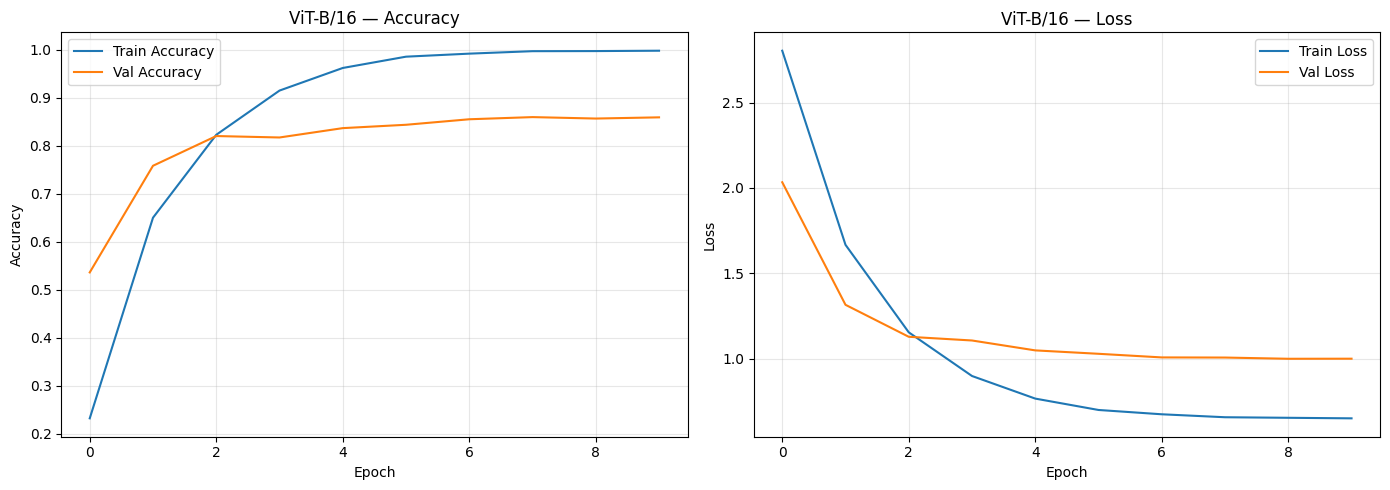

In [5]:
def plot_vit_results(history, filename="vit_learning_curves.png"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].set_title('ViT-B/16 — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].set_title('ViT-B/16 — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    os.makedirs('../results/figures', exist_ok=True)
    save_path = os.path.join('../results/figures', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    plt.show()

plot_vit_results(history)

In [6]:
# Save the final model
model.save('../results/models/vit.keras')
print("Final ViT model saved to ../results/models/vit.keras")

# Print final metrics
print(f"\nBest Validation Loss:      {min(history.history['val_loss']):.4f}")
print(f"Best Validation Accuracy:  {max(history.history['val_accuracy']):.4f}")
print(f"Best Validation F1-macro:  {max(history.history['val_f1_macro']):.4f}")
print(f"\nFinal Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training F1-macro:   {history.history['f1_macro'][-1]:.4f}")
print(f"Final Validation F1-macro: {history.history['val_f1_macro'][-1]:.4f}")

print(f"\nTraining config:")
print(f"  Epochs run: {len(history.history['loss'])}/{EPOCHS}")
print(f"  LR: {LEARNING_RATE}, Dropout: {DROPOUT_RATE}, Dense: {DENSE_UNITS}")
print(f"  Weight decay: {WEIGHT_DECAY}, Label smoothing: {LABEL_SMOOTHING}")
print(f"  Warmup: {WARMUP_FRACTION*100:.0f}% of {TOTAL_STEPS} steps")

Final ViT model saved to ../results/models/vit.keras

Best Validation Loss:      0.9990
Best Validation Accuracy:  0.8601
Best Validation F1-macro:  0.8453

Final Training Accuracy:   0.9985
Final Validation Accuracy: 0.8596
Final Training F1-macro:   0.9983
Final Validation F1-macro: 0.8448

Training config:
  Epochs run: 10/10
  LR: 3e-05, Dropout: 0.3, Dense: 256
  Weight decay: 0.01, Label smoothing: 0.1
  Warmup: 10% of 5840 steps
